In [10]:
from mplsoccer import Sbopen

parser = Sbopen(dataframe=True)
events, related, freeze, tactics = parser.event(3930158)

# если есть 360 для матча:
frames, visible = parser.frame(3930158)

In [11]:
df_lineup = parser.lineup(3930158)
df_lineup = df_lineup[['player_id', 'jersey_number']]

In [6]:
events['type_name'].unique()

array(['Starting XI', 'Half Start', 'Pass', 'Ball Receipt', 'Carry',
       'Duel', 'Ball Recovery', 'Pressure', 'Block', 'Clearance',
       'Interception', 'Dribble', 'Dispossessed', 'Miscontrol',
       'Foul Committed', 'Foul Won', '50/50', 'Shot', 'Goal Keeper',
       'Dribbled Past', 'Tactical Shift', 'Half End', 'Substitution',
       'Error', 'Own Goal For', 'Own Goal Against'], dtype=object)

In [2]:
visible

,match_id,id,visible_area
0,3930158,df6f6fb7-f0b0-4561-9171-f4172f5e97e7,"[120.0, 80.0, 0.0, 80.0, 0.0, 78.6625660155719..."
1,3930158,f9195e75-1617-478c-bf9d-66f17151724a,"[0.0, 80.0, 0.0, 75.09926103829372, 43.0453240..."
2,3930158,65072c25-9c61-441e-a51c-52856c51ca94,"[0.0, 80.0, 0.0, 75.09926103829372, 43.0453240..."
3,3930158,01be895c-5835-4a8d-b99f-2a642f5d26dc,"[0.0, 80.0, 0.0, 77.5741290598231, 40.12004596..."
4,3930158,9aa6c033-3015-4e13-9566-bd1913f754d3,"[61.76035625021637, 80.0, 60.73189700409275, 2..."
...,...,...,...
3083,3930158,6e82ff86-8623-4eef-9273-97bbbb7fba7e,"[93.02340295475781, 76.58606099971738, 76.6056..."
3084,3930158,0857af32-3e3a-401c-b3f1-7b976394abcc,"[0.0, 80.0, 0.0, 32.10424678591358, 24.3491226..."
3085,3930158,6ed1aa99-3539-41d1-9dcd-27badaa5e837,"[94.41712379163776, 78.27051676556354, 78.5271..."
3086,3930158,2b19ee68-fd2c-4430-9e9b-1ae2d3b24388,"[0.0, 80.0, 0.0, 30.320299859988673, 24.458075..."


### Попытка в поивентвое описание

In [3]:
import matplotlib.pyplot as plt
from statsbomb_toolkit import (
    GigaChatClient,
    build_360_index,
    build_events_df,
    clean_event_recursive,
    draw_event_keep_style,
    save_event_figure,
    standardize_events_and_360,
)


In [12]:
df_events = build_events_df(events, df_lineup, frames=frames)
frames_by_id, visible_by_id = build_360_index(frames, visible)

In [10]:
frames_by_id

{'001ad131-fad7-4269-9611-bd2ee7669532':        teammate  actor  keeper  match_id  \
 20402      True  False   False   3930158   
 20403      True  False   False   3930158   
 20404     False  False   False   3930158   
 20405     False  False   False   3930158   
 20406      True  False   False   3930158   
 20407      True   True   False   3930158   
 20408      True  False   False   3930158   
 20409     False  False   False   3930158   
 20410     False  False   False   3930158   
 20411     False  False   False   3930158   
 20412     False  False   False   3930158   
 20413     False  False   False   3930158   
 20414     False  False    True   3930158   
 
                                          id           x          y  
 20402  001ad131-fad7-4269-9611-bd2ee7669532   90.716867  35.975183  
 20403  001ad131-fad7-4269-9611-bd2ee7669532   92.766666  49.559137  
 20404  001ad131-fad7-4269-9611-bd2ee7669532   94.240812  37.111987  
 20405  001ad131-fad7-4269-9611-bd2ee7669532   9

In [107]:
visible_by_id

{'df6f6fb7-f0b0-4561-9171-f4172f5e97e7': [120.0,
  80.0,
  0.0,
  80.0,
  0.0,
  78.66256601557194,
  43.78782055064254,
  0.0,
  80.0218676843286,
  0.0,
  120.0,
  72.93416347206649,
  120.0,
  80.0],
 'f9195e75-1617-478c-bf9d-66f17151724a': [0.0,
  80.0,
  0.0,
  75.09926103829372,
  43.045324003661904,
  0.0,
  74.72610039992077,
  0.0,
  113.17407268840394,
  80.0,
  0.0,
  80.0],
 '65072c25-9c61-441e-a51c-52856c51ca94': [0.0,
  80.0,
  0.0,
  75.09926103829372,
  43.045324003661904,
  0.0,
  74.72610039992077,
  0.0,
  113.17407268840394,
  80.0,
  0.0,
  80.0],
 '01be895c-5835-4a8d-b99f-2a642f5d26dc': [0.0,
  80.0,
  0.0,
  77.5741290598231,
  40.120045966551885,
  0.0,
  76.23413795790303,
  0.0,
  111.17163904130139,
  80.0,
  0.0,
  80.0],
 '9aa6c033-3015-4e13-9566-bd1913f754d3': [61.76035625021637,
  80.0,
  60.73189700409275,
  2.7928945090636,
  66.62756880293122,
  0.0,
  91.67988801831513,
  0.0,
  120.0,
  33.44500836718267,
  120.0,
  80.0,
  61.76035625021637,
  80.0]

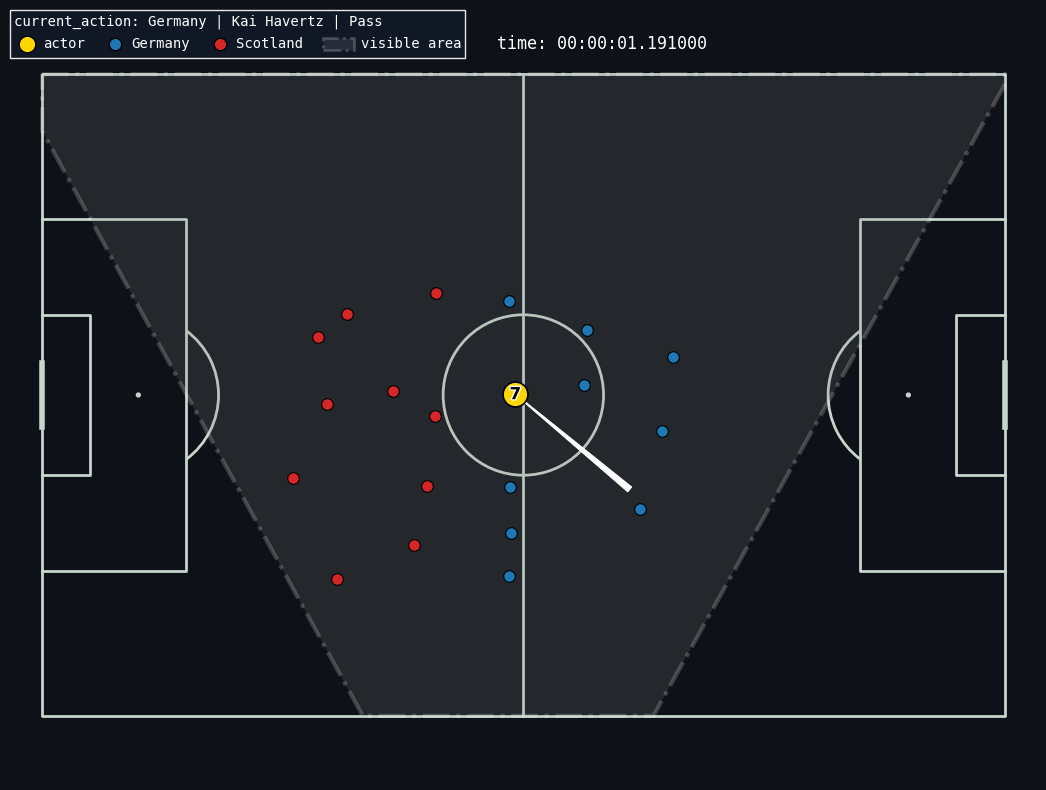

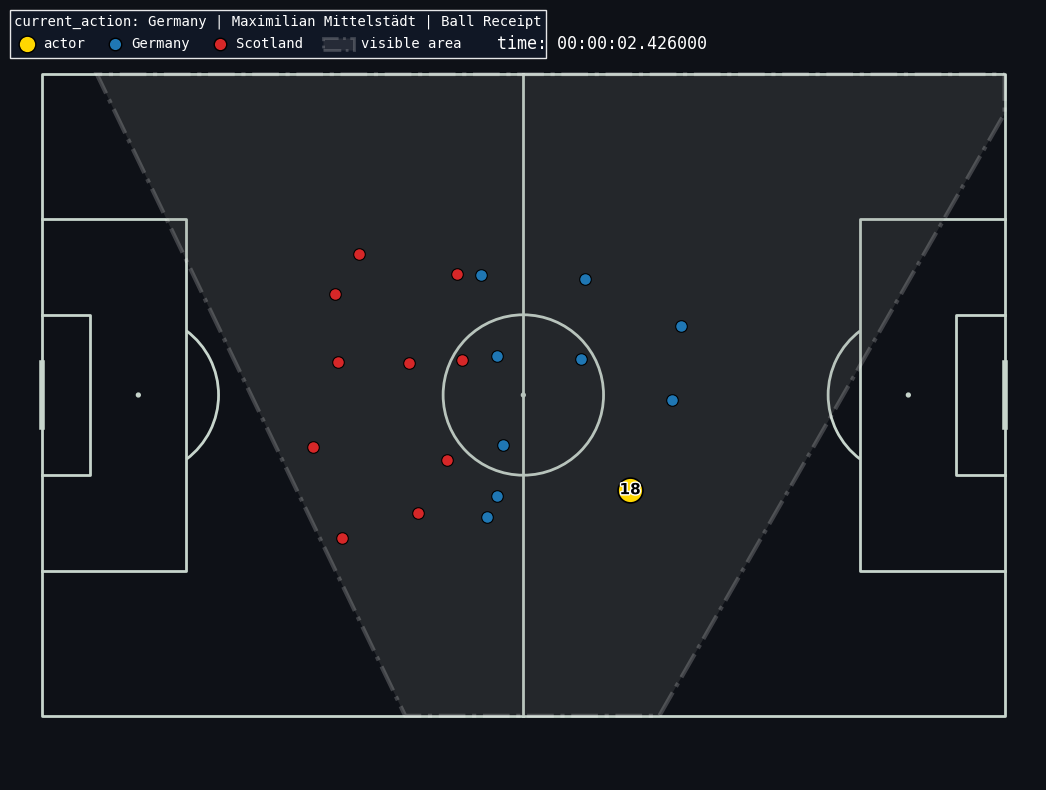

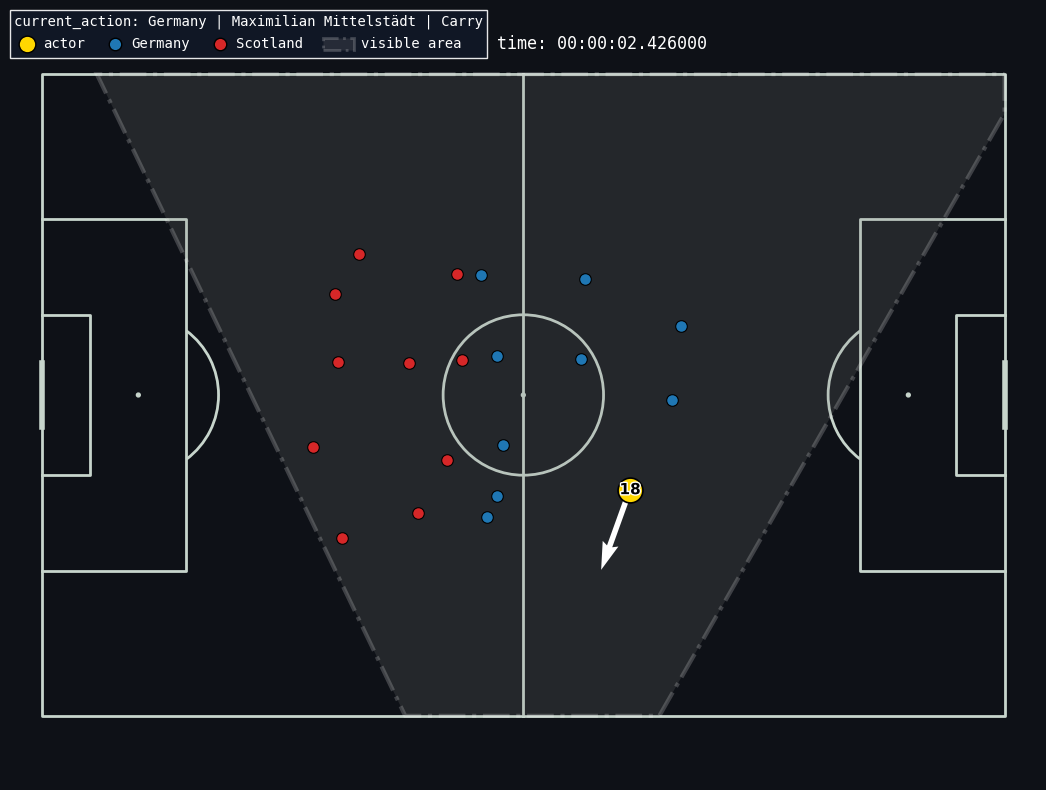

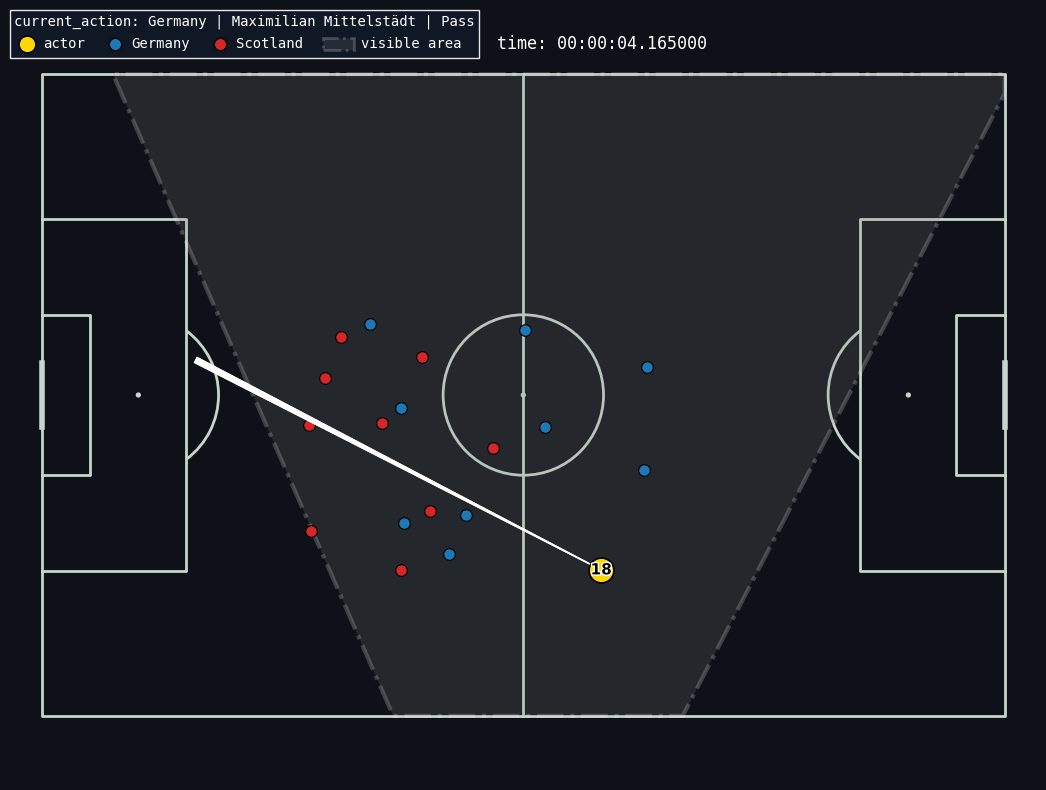

In [9]:
for el in df_events.id.to_list()[4:8]:
    fig, ax = draw_event_keep_style(df_events, el, frames_by_id, visible_by_id)
    plt.show()

### Стандартизация событийных ивентов и 360-данных, чтобы отправлять уже стандартизированные данные с фиксированной камерой и координатами в LLM

In [6]:
import json

with open("3930158 (2).json", "r", encoding="utf-8") as f:
    events_raw = json.load(f)

with open("3930158 (1).json", "r", encoding="utf-8") as f:
    three_sixty_raw = json.load(f)

events_std, three_sixty_std, flip_map = standardize_events_and_360(
    events_raw, three_sixty_raw,
    reference_team="Scotland"
)

# сохранить “уже выровненный” матч
with open("3930158_std_events.json", "w", encoding="utf-8") as f:
    json.dump(events_std, f, ensure_ascii=False, indent=2)

with open("3930158_std_360.json", "w", encoding="utf-8") as f:
    json.dump(three_sixty_std, f, ensure_ascii=False, indent=2)

In [16]:
events_std[0]

{'id': 'f2207d37-beed-4073-84a5-f9d696e2afdd',
 'index': 1,
 'period': 1,
 'timestamp': '00:00:00.000',
 'minute': 0,
 'second': 0,
 'type': {'id': 35, 'name': 'Starting XI'},
 'possession': 1,
 'possession_team': {'id': 770, 'name': 'Germany'},
 'play_pattern': {'id': 1, 'name': 'Regular Play'},
 'team': {'id': 770, 'name': 'Germany'},
 'duration': 0.0,
 'tactics': {'formation': 4231,
  'lineup': [{'player': {'id': 5570, 'name': 'Manuel Neuer'},
    'position': {'id': 1, 'name': 'Goalkeeper'},
    'jersey_number': 1},
   {'player': {'id': 5579, 'name': 'Joshua Kimmich'},
    'position': {'id': 2, 'name': 'Right Back'},
    'jersey_number': 6},
   {'player': {'id': 3167, 'name': 'Antonio Rüdiger'},
    'position': {'id': 3, 'name': 'Right Center Back'},
    'jersey_number': 2},
   {'player': {'id': 8221, 'name': 'Jonathan Tah'},
    'position': {'id': 5, 'name': 'Left Center Back'},
    'jersey_number': 4},
   {'player': {'id': 12407, 'name': 'Maximilian Mittelstädt'},
    'position': 

In [33]:
three_sixty_std[0]

{'event_uuid': 'df6f6fb7-f0b0-4561-9171-f4172f5e97e7',
 'visible_area': [0.0,
  0.0,
  120.0,
  0.0,
  120.0,
  1.3374339844280598,
  76.21217944935745,
  80.0,
  39.9781323156714,
  80.0,
  0.0,
  7.065836527933513,
  0.0,
  0.0],
 'freeze_frame': [{'teammate': True,
   'actor': False,
   'keeper': False,
   'location': [78.70157419277533, 35.299591845488926]},
  {'teammate': True,
   'actor': False,
   'keeper': False,
   'location': [77.30662332649237, 44.46469896240462]},
  {'teammate': True,
   'actor': False,
   'keeper': False,
   'location': [74.50206382230505, 54.220510079847195]},
  {'teammate': True,
   'actor': False,
   'keeper': False,
   'location': [67.91709655763836, 31.896717430946737]},
  {'teammate': True,
   'actor': False,
   'keeper': False,
   'location': [67.51816725273716, 38.71126171432842]},
  {'teammate': True,
   'actor': True,
   'keeper': False,
   'location': [59.0, 39.900001525878906]},
  {'teammate': True,
   'actor': False,
   'keeper': False,
   'lo

### Очистка ивентового событий от не нужных полей (id + possesion_team + pass.angle)

In [17]:
event_clean = clean_event_recursive(
    events_std[4],
    keep_event_id=True,
    keep_id_paths={("player", "id")},            # оставить player_id
    drop_keys_global={"possession", "possession_team"},
    drop_paths={("pass", "angle")},
)

In [18]:
event_clean

{'id': 'df6f6fb7-f0b0-4561-9171-f4172f5e97e7',
 'index': 5,
 'period': 1,
 'timestamp': '00:00:01.191',
 'minute': 0,
 'second': 1,
 'type': {'name': 'Pass'},
 'play_pattern': {'name': 'From Kick Off'},
 'team': {'name': 'Germany'},
 'player': {'id': 8966, 'name': 'Kai Havertz'},
 'position': {'name': 'Center Forward'},
 'location': [59.0, 39.9],
 'duration': 1.234945,
 'related_events': ['f9195e75-1617-478c-bf9d-66f17151724a'],
 'pass': {'recipient': {'name': 'Maximilian Mittelstädt'},
  'length': 18.603764,
  'height': {'name': 'Ground Pass'},
  'end_location': [73.3, 51.8],
  'body_part': {'name': 'Left Foot'},
  'type': {'name': 'Kick Off'}},
 '_flip180': True,
 '_reference_team': 'Scotland'}

In [66]:
from pprint import pprint
pprint(event_clean, sort_dicts=False)

{'id': 'df6f6fb7-f0b0-4561-9171-f4172f5e97e7',
 'index': 5,
 'period': 1,
 'timestamp': '00:00:01.191',
 'minute': 0,
 'second': 1,
 'type': {'name': 'Pass'},
 'play_pattern': {'name': 'From Kick Off'},
 'team': {'name': 'Germany'},
 'player': {'id': 8966, 'name': 'Kai Havertz'},
 'position': {'name': 'Center Forward'},
 'location': [59.0, 39.9],
 'duration': 1.234945,
 'related_events': ['f9195e75-1617-478c-bf9d-66f17151724a'],
 'pass': {'recipient': {'name': 'Maximilian Mittelstädt'},
          'length': 18.603764,
          'height': {'name': 'Ground Pass'},
          'end_location': [73.3, 51.8],
          'body_part': {'name': 'Left Foot'},
          'type': {'name': 'Kick Off'}},
 '_flip180': True,
 '_reference_team': 'Scotland'}


### Работа с API Gigachat

In [40]:
import os, importlib
from dotenv import load_dotenv
import statsbomb_toolkit.gigachat as gc

load_dotenv(override=True)
importlib.reload(gc)

GigaChatClient = gc.GigaChatClient
GigaChatAPIError = gc.GigaChatAPIError

key = os.getenv("GIGACHAT_BASIC_AUTH", "").strip().strip('"').strip("'")
print("key_set:", bool(key), "len:", len(key), "prefix:", key[:10])

client = GigaChatClient(
    auth_key=key,
    auth_scheme="Basic",  # для oauth чаще всего нужно именно Basic
    ca_bundle="russian_trusted_root_ca.pem",
)
token = client.get_access_token()
print("token ok:", token[:16], "...")

key_set: True len: 100 prefix: MDE5Yzc1ND
token ok: eyJjdHkiOiJqd3Qi ...


In [39]:
models = client.list_models()
for m in models["data"]:
    if m.get("type") == "chat":
        print(m["id"])

GigaChat
GigaChat-2
GigaChat-2-Max
GigaChat-2-Pro
GigaChat-Max
GigaChat-Max-preview
GigaChat-Plus
GigaChat-Pro
GigaChat-Pro-preview
GigaChat-preview


In [8]:
# Получаем 30-минутный Bearer токен через скрытый постоянный Basic key
access_token = client.get_access_token()
print(f"token_prefix={access_token[:16]}... len={len(access_token)}")


token_prefix=eyJjdHkiOiJqd3Qi... len=1233


### Тестовый прогон для одного события

In [10]:
# Строим индекс 360 по event_uuid для корректной привязки к событию
sb360_by_event_id = {
    item.get("event_uuid") or item.get("id"): item
    for item in three_sixty_std
}


In [20]:
# Берём то же событие, которое визуализируем, и находим его в JSON по id
event_id = df_events.id[4]
events_by_id = {e.get("id"): e for e in events_std}

event_raw_for_prompt = events_by_id[event_id]
event_clean = clean_event_recursive(
    event_raw_for_prompt,
    keep_event_id=True,
    keep_id_paths={("player", "id")},
    drop_keys_global={"possession", "possession_team"},
    drop_paths={("pass", "angle")},
)
sb360_event = sb360_by_event_id.get(event_id)


In [21]:
event_clean

{'id': 'df6f6fb7-f0b0-4561-9171-f4172f5e97e7',
 'index': 5,
 'period': 1,
 'timestamp': '00:00:01.191',
 'minute': 0,
 'second': 1,
 'type': {'name': 'Pass'},
 'play_pattern': {'name': 'From Kick Off'},
 'team': {'name': 'Germany'},
 'player': {'id': 8966, 'name': 'Kai Havertz'},
 'position': {'name': 'Center Forward'},
 'location': [59.0, 39.9],
 'duration': 1.234945,
 'related_events': ['f9195e75-1617-478c-bf9d-66f17151724a'],
 'pass': {'recipient': {'name': 'Maximilian Mittelstädt'},
  'length': 18.603764,
  'height': {'name': 'Ground Pass'},
  'end_location': [73.3, 51.8],
  'body_part': {'name': 'Left Foot'},
  'type': {'name': 'Kick Off'}},
 '_flip180': True,
 '_reference_team': 'Scotland'}

In [22]:
sb360_event

{'event_uuid': 'df6f6fb7-f0b0-4561-9171-f4172f5e97e7',
 'visible_area': [0.0,
  0.0,
  120.0,
  0.0,
  120.0,
  1.3374339844280598,
  76.21217944935745,
  80.0,
  39.9781323156714,
  80.0,
  0.0,
  7.065836527933513,
  0.0,
  0.0],
 'freeze_frame': [{'teammate': True,
   'actor': False,
   'keeper': False,
   'location': [78.70157419277533, 35.299591845488926]},
  {'teammate': True,
   'actor': False,
   'keeper': False,
   'location': [77.30662332649237, 44.46469896240462]},
  {'teammate': True,
   'actor': False,
   'keeper': False,
   'location': [74.50206382230505, 54.220510079847195]},
  {'teammate': True,
   'actor': False,
   'keeper': False,
   'location': [67.91709655763836, 31.896717430946737]},
  {'teammate': True,
   'actor': False,
   'keeper': False,
   'location': [67.51816725273716, 38.71126171432842]},
  {'teammate': True,
   'actor': True,
   'keeper': False,
   'location': [59.0, 39.900001525878906]},
  {'teammate': True,
   'actor': False,
   'keeper': False,
   'lo

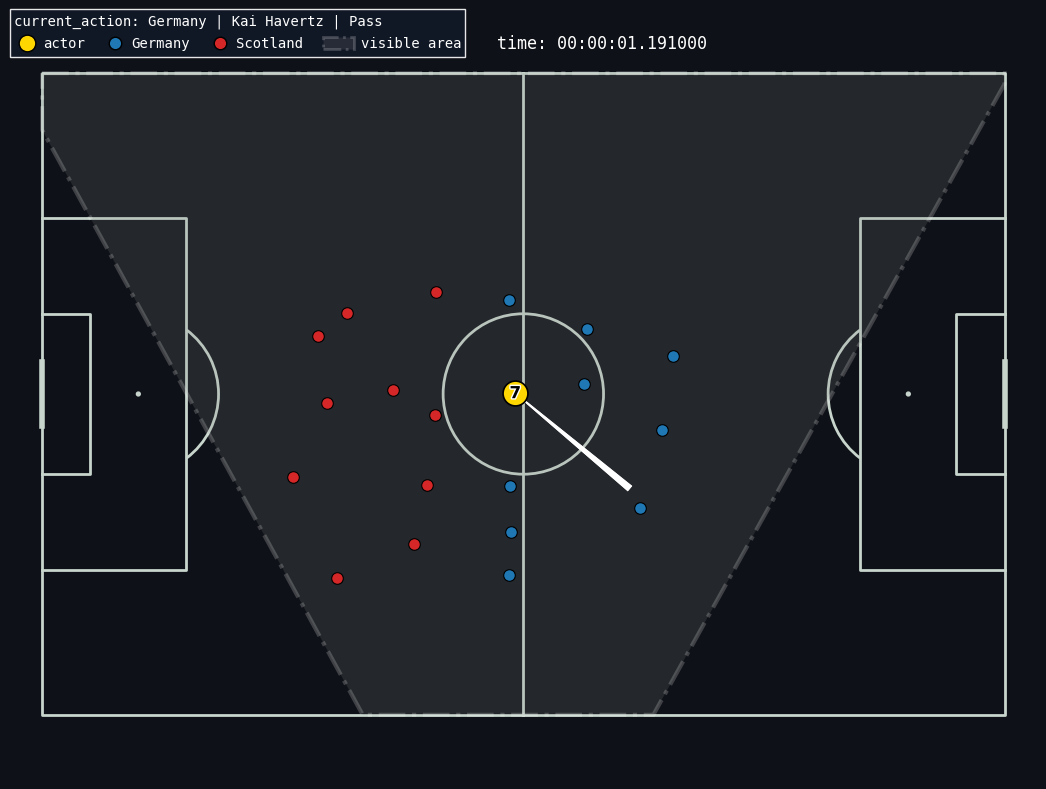

In [43]:
fig, ax = draw_event_keep_style(df_events, event_id, frames_by_id, visible_by_id)

### Обработка событий ['Pass', 'Ball Receipt', 'Carry','Duel']

In [11]:
slice = df_events[df_events.type_name.isin(['Pass', 'Ball Receipt', 'Carry','Duel'])]

In [18]:
slice

,id,index,period,timestamp,team_name,event_player_id,event_player_name,type_name,event_x,event_y,event_end_x,event_end_y,event_jersey_number,has_360,timestring
4,df6f6fb7-f0b0-4561-9171-f4172f5e97e7,5,1,00:00:01.191000,Germany,8966.0,Kai Havertz,Pass,61.0,40.1,46.7,28.2,7.0,True,00:00
5,f9195e75-1617-478c-bf9d-66f17151724a,6,1,00:00:02.426000,Germany,12407.0,Maximilian Mittelstädt,Ball Receipt,46.7,28.2,NaN,NaN,18.0,True,00:00
6,65072c25-9c61-441e-a51c-52856c51ca94,7,1,00:00:02.426000,Germany,12407.0,Maximilian Mittelstädt,Carry,46.7,28.2,50.3,18.2,18.0,True,00:00
7,01be895c-5835-4a8d-b99f-2a642f5d26dc,8,1,00:00:04.165000,Germany,12407.0,Maximilian Mittelstädt,Pass,50.3,18.2,100.9,44.4,18.0,True,00:00
8,9aa6c033-3015-4e13-9566-bd1913f754d3,9,1,00:00:07.397000,Germany,8966.0,Kai Havertz,Ball Receipt,100.9,44.4,NaN,NaN,7.0,True,00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3361,41424045-5ee8-4bd5-b3ed-57d042439a23,3362,2,00:47:29.522000,Germany,3053.0,Leroy Sané,Pass,98.7,19.1,110.3,23.9,19.0,True,00:47
3363,cadaaaca-6fad-4d93-a97c-31d2a8321e24,3364,2,00:47:30.334000,Germany,5562.0,Thomas Müller,Ball Receipt,110.3,23.9,NaN,NaN,13.0,True,00:47
3364,e4e23d31-0422-4527-b0ba-7ff04e7e1fde,3365,2,00:47:30.334000,Germany,5562.0,Thomas Müller,Pass,109.3,28.5,96.5,36.6,13.0,True,00:47
3365,782a4655-67f2-4bfa-8a7e-5dce3811e292,3366,2,00:47:31.725000,Germany,3493.0,Emre Can,Ball Receipt,96.5,36.6,NaN,NaN,25.0,True,00:47


In [67]:
file_id = client.upload_file(img_path, purpose="general")
print(file_id)


d3783297-40c1-4758-83e3-9af916b53612


In [ ]:
for _, el in slice.head(20).iterrows():
    eid = el["id"]

    event_raw = events_by_id[eid]
    event_clean = clean_event_recursive(
        event_raw,
        keep_event_id=True,
        keep_id_paths={("player", "id")},
        drop_keys_global={"possession", "possession_team"},
        drop_paths={("pass", "angle")},
    )

    sb360_event = sb360_by_event_id.get(eid)
    file_id = None

    fig, ax = draw_event_keep_style(df_events, eid, frames_by_id, visible_by_id)
    img_path = save_event_figure(fig, eid)
    plt.close(fig)
    file_id = client.upload_file(img_path, purpose="general")

    result = client.generate_commentary(
        event_json=event_clean,
        sb360_json=sb360_event,          # None для событий без 360
        image_attachment_id=file_id,     # None для событий без картинки
        temperature=0.03,
    )
    client.append_commentary_result_to_txt(result, "outputs/commentary_log.txt", event_id=eid)


GigaChatAPIError: Chat completion failed: HTTP 402: Payment Required

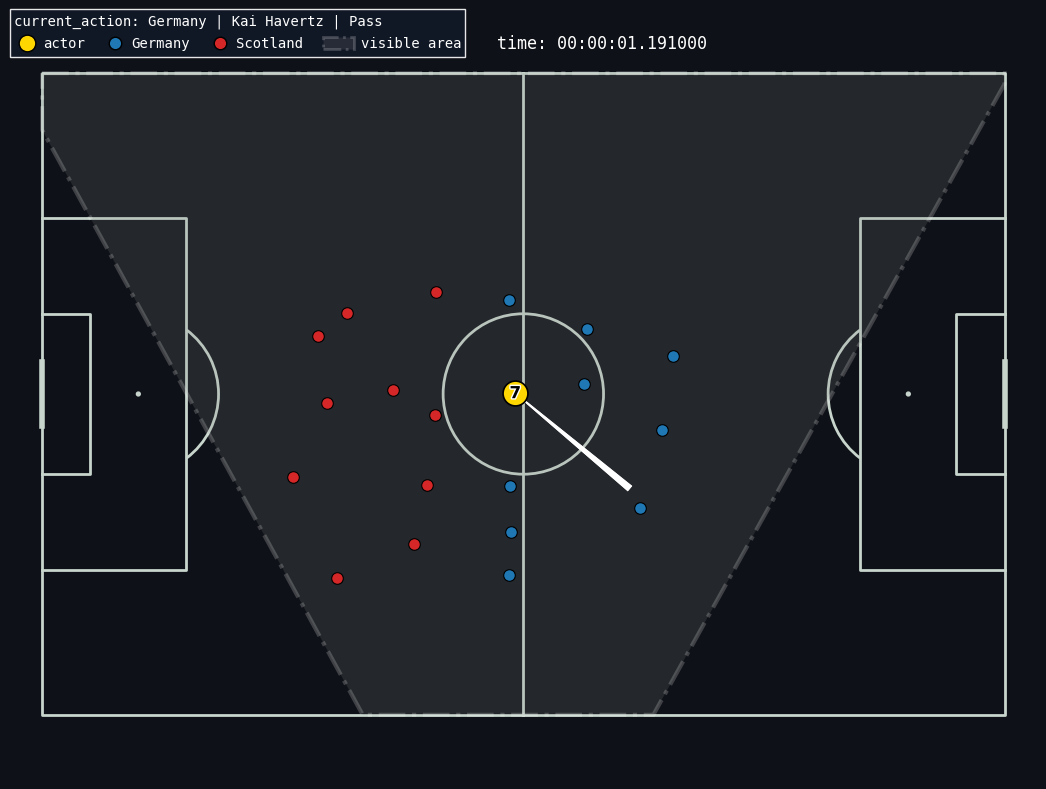

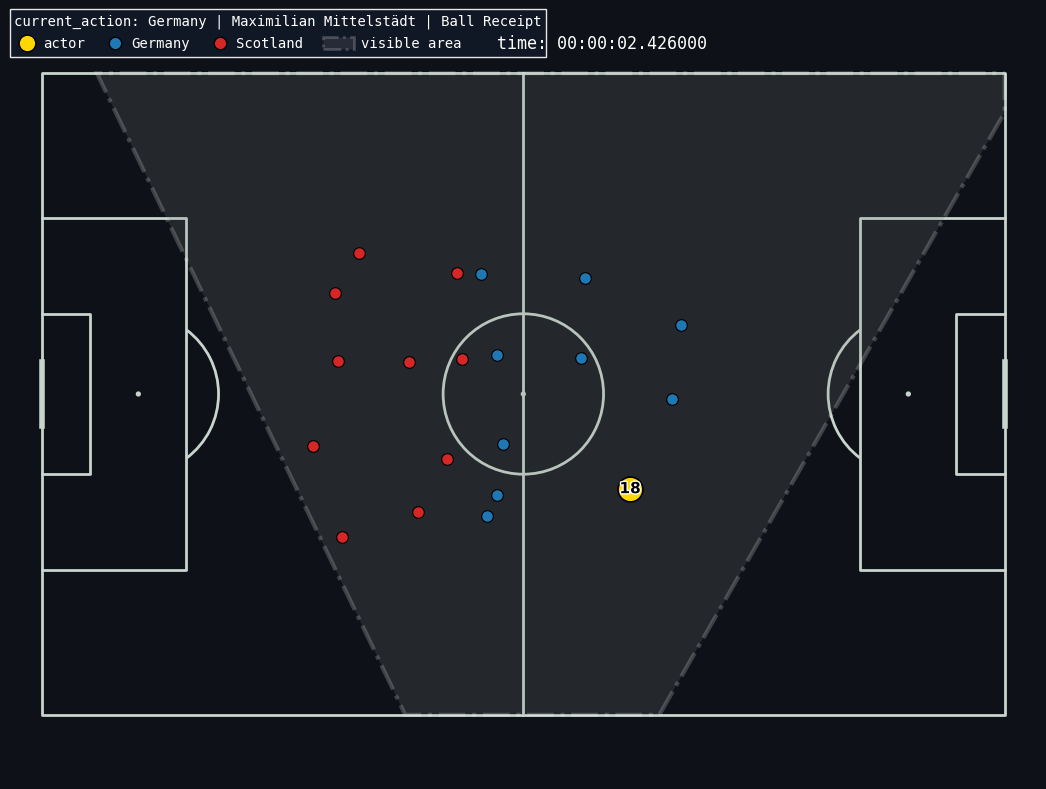

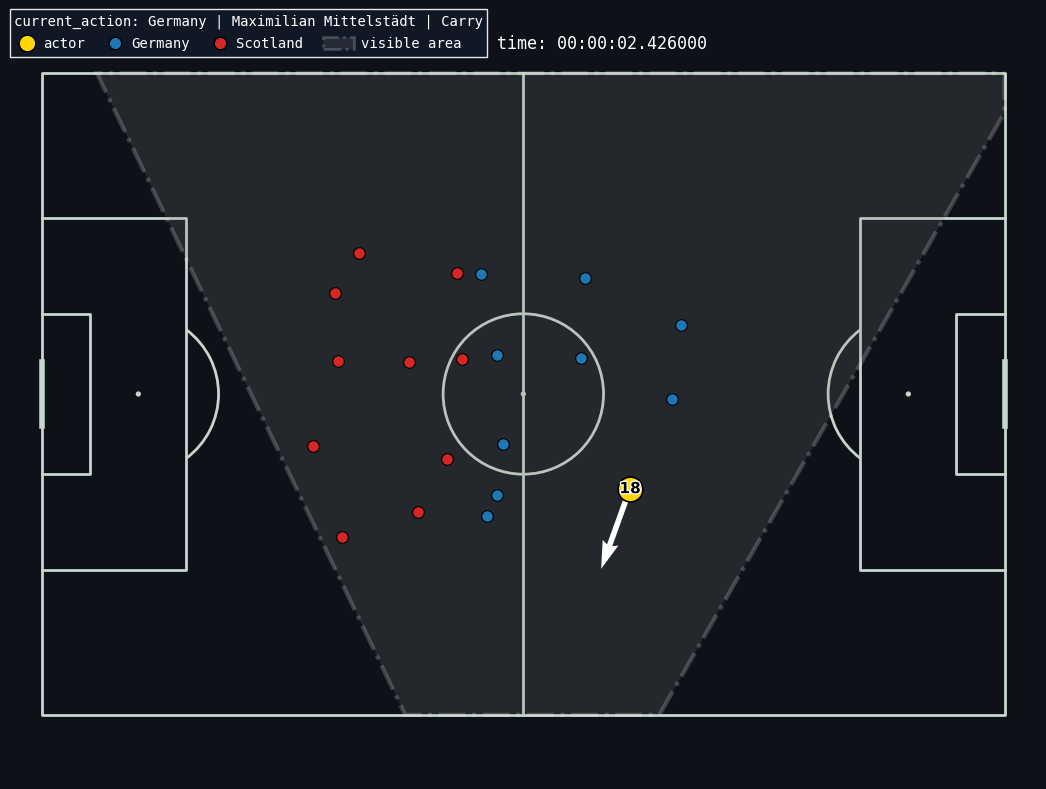

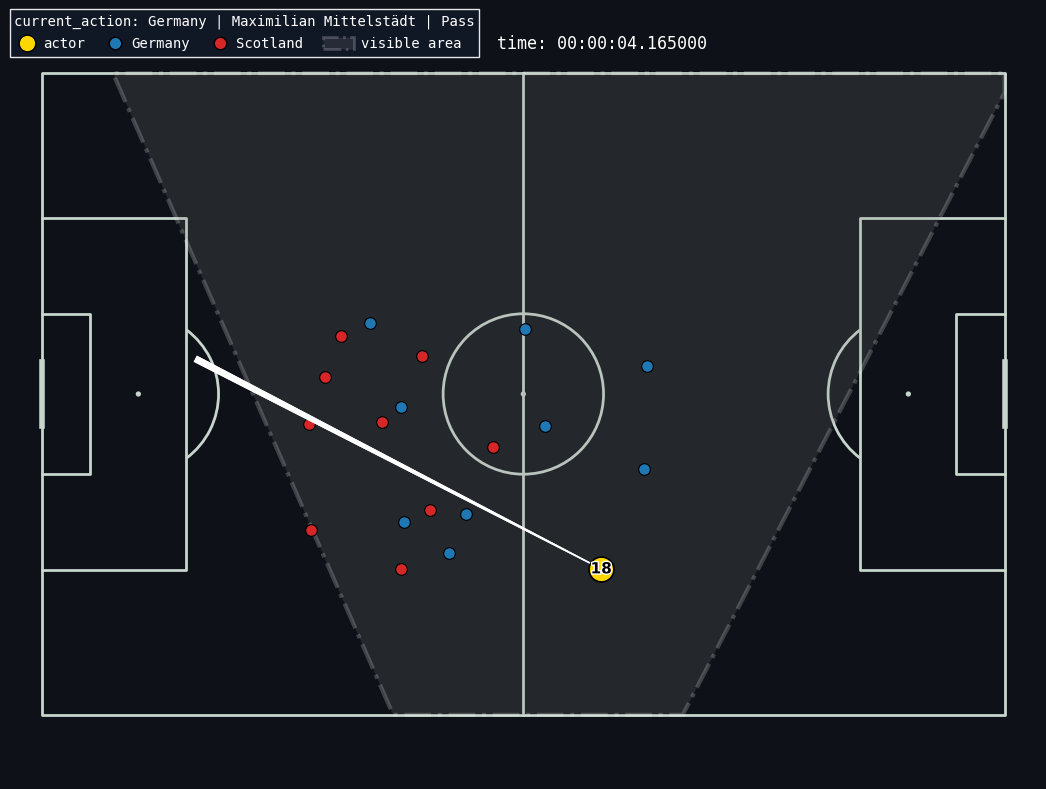

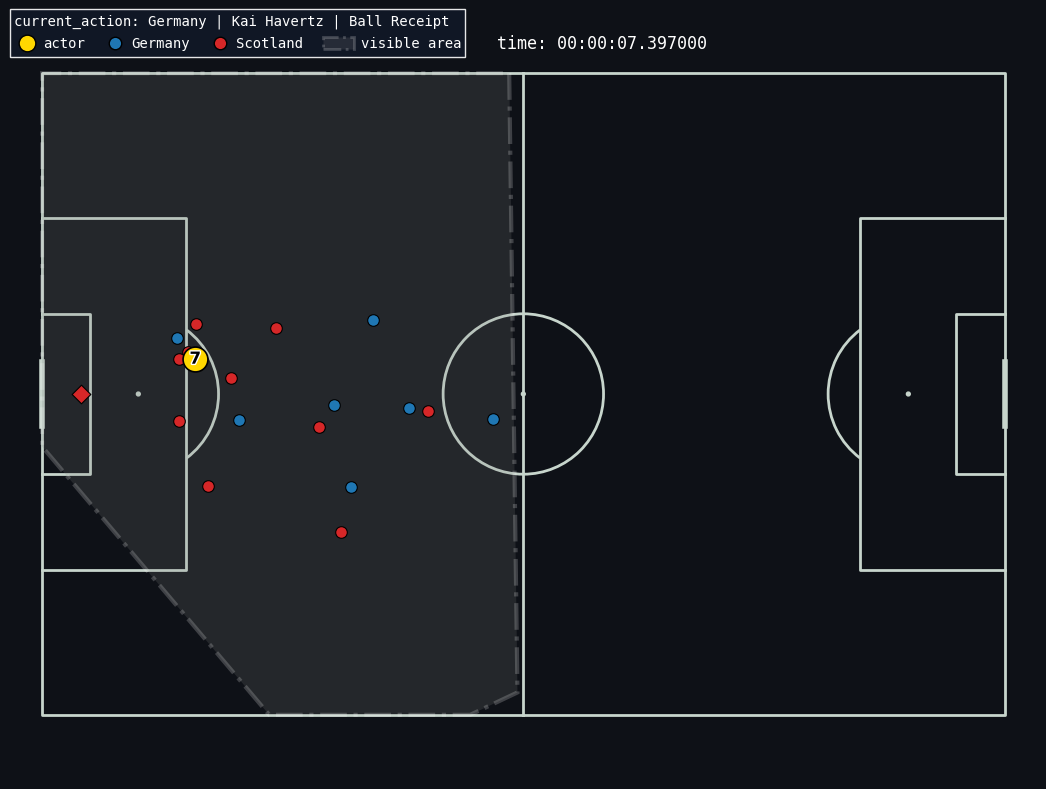

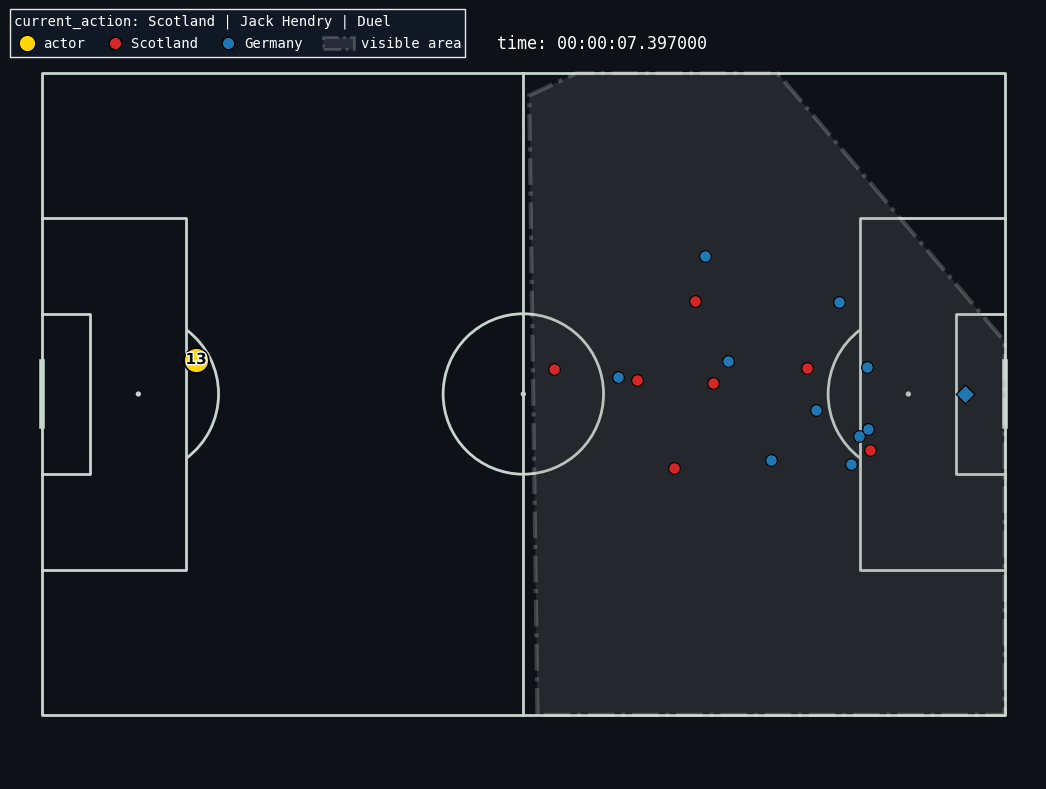

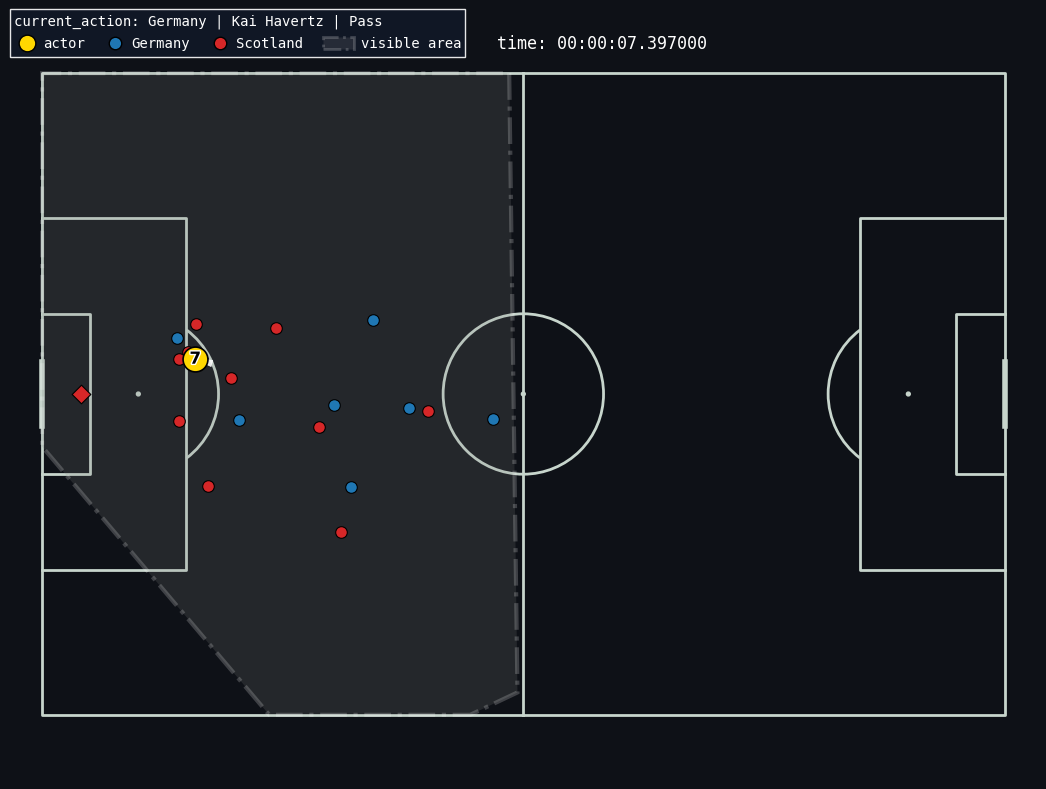

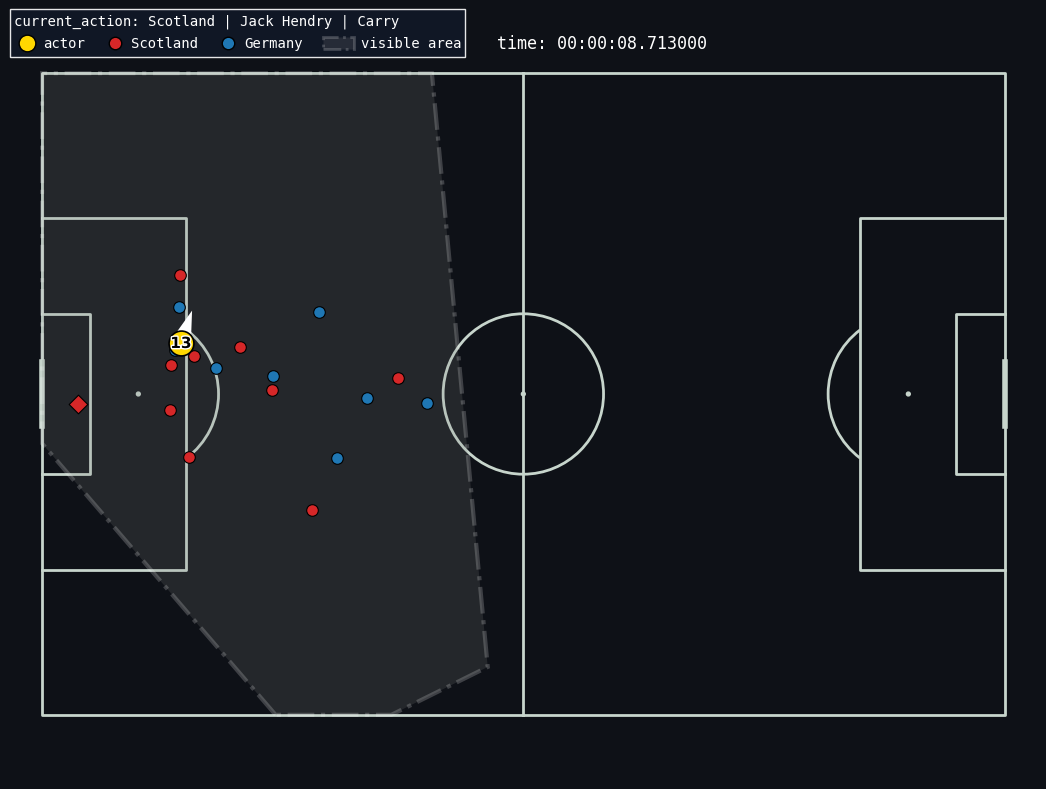

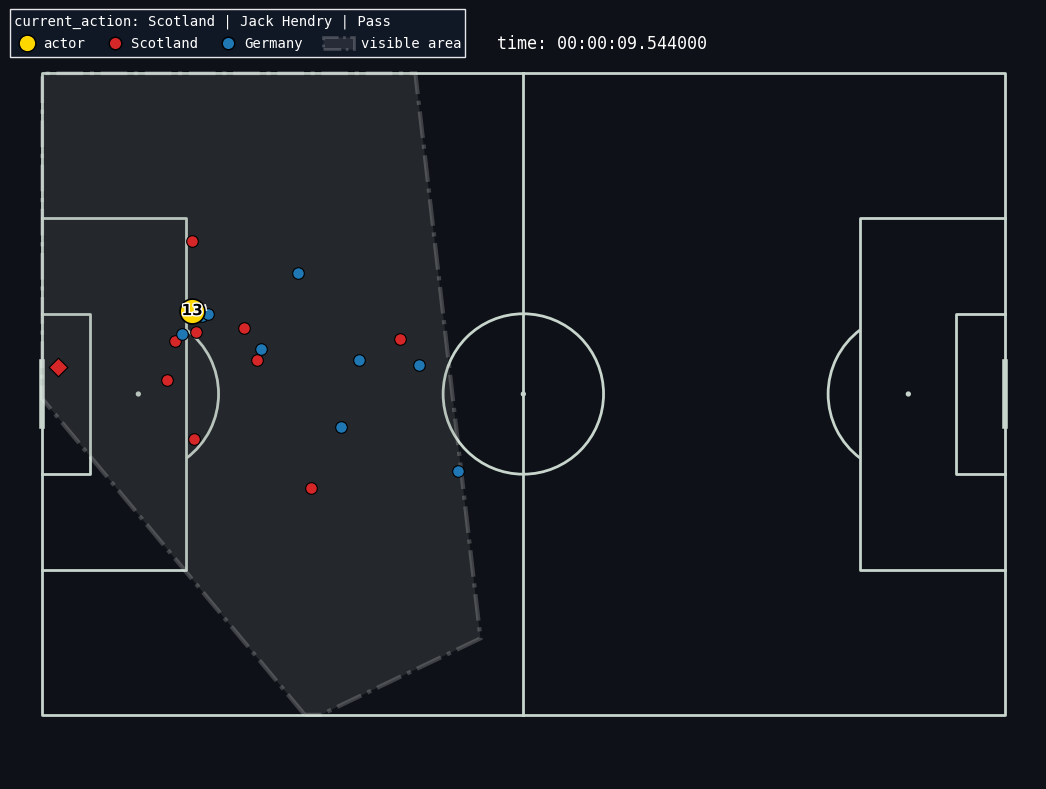

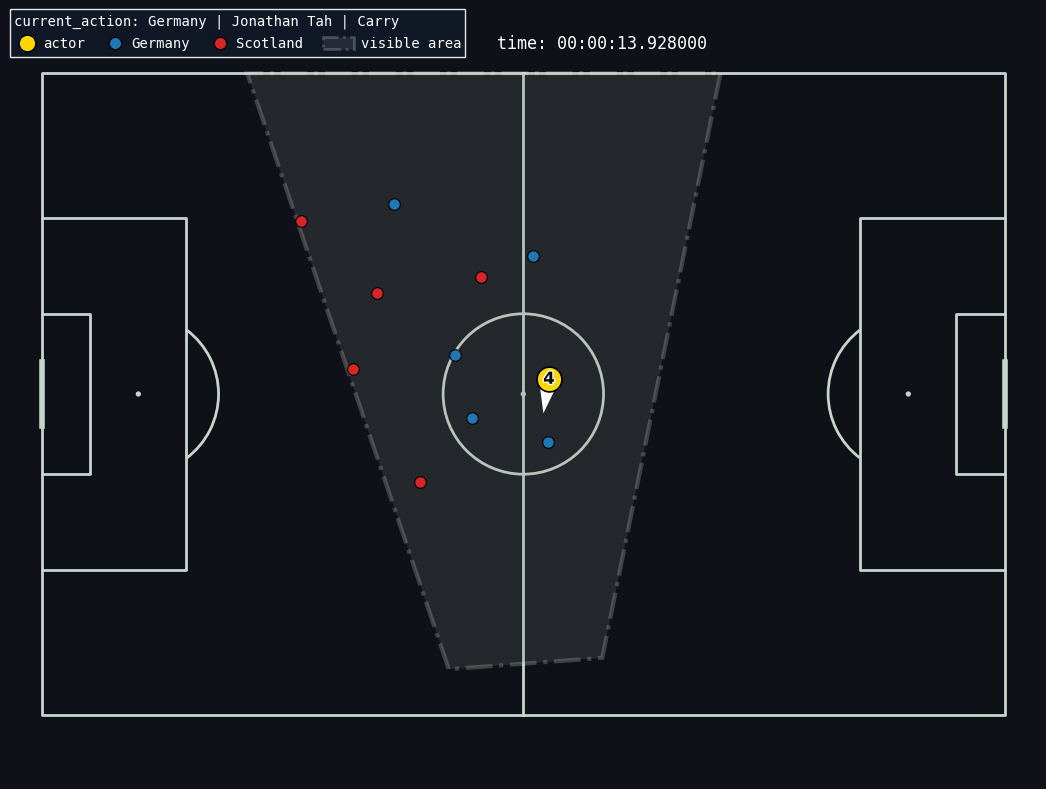

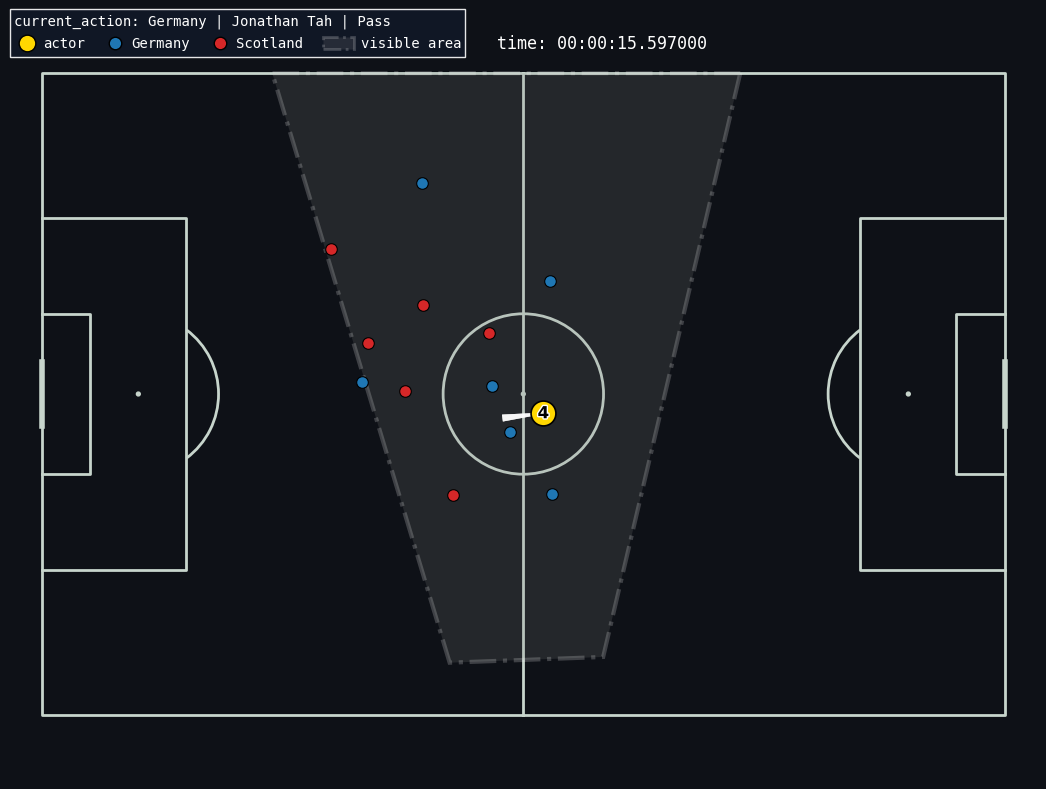

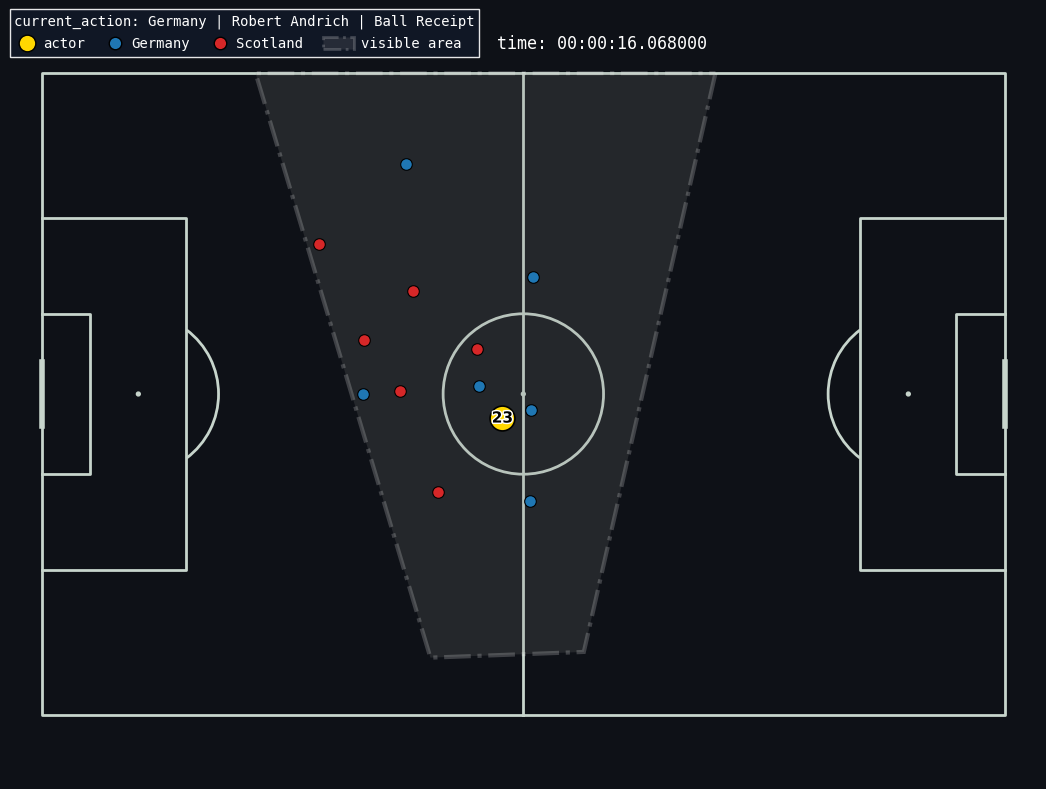

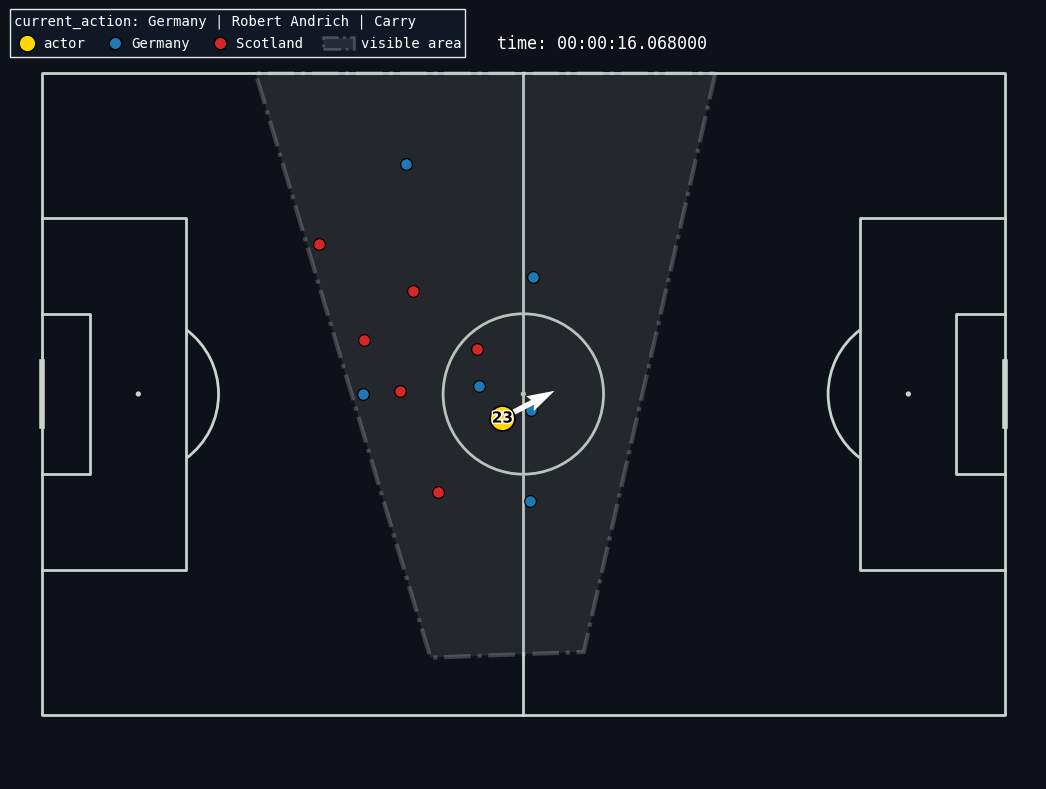

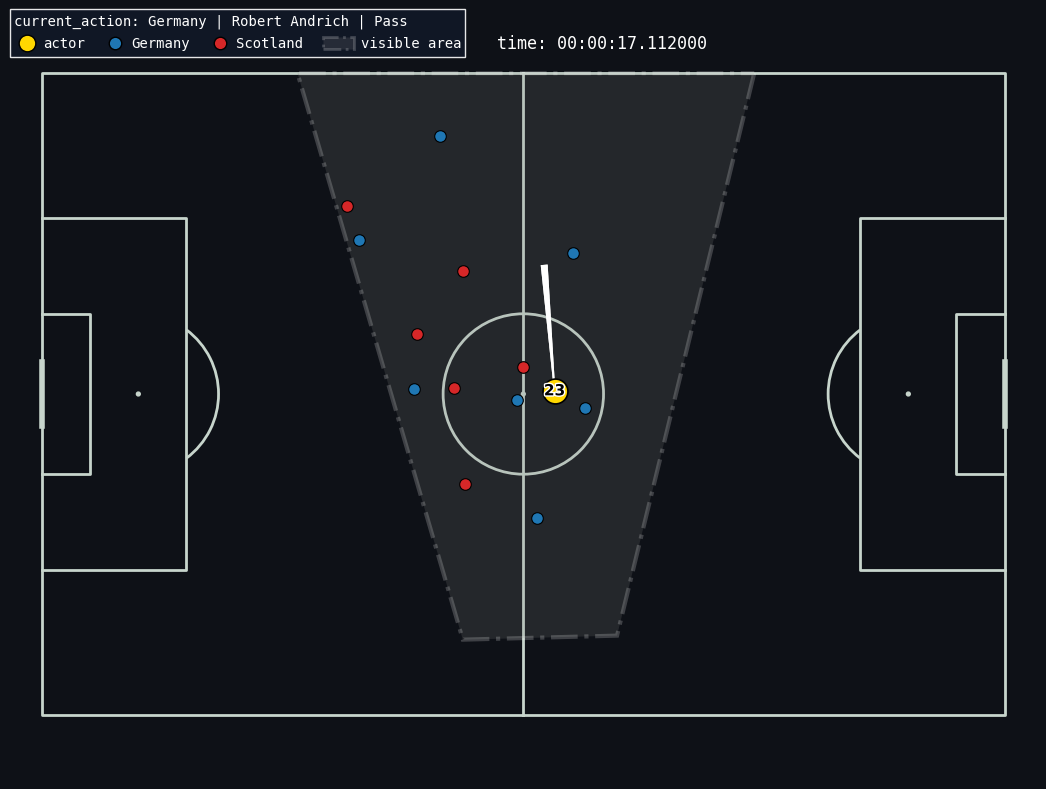

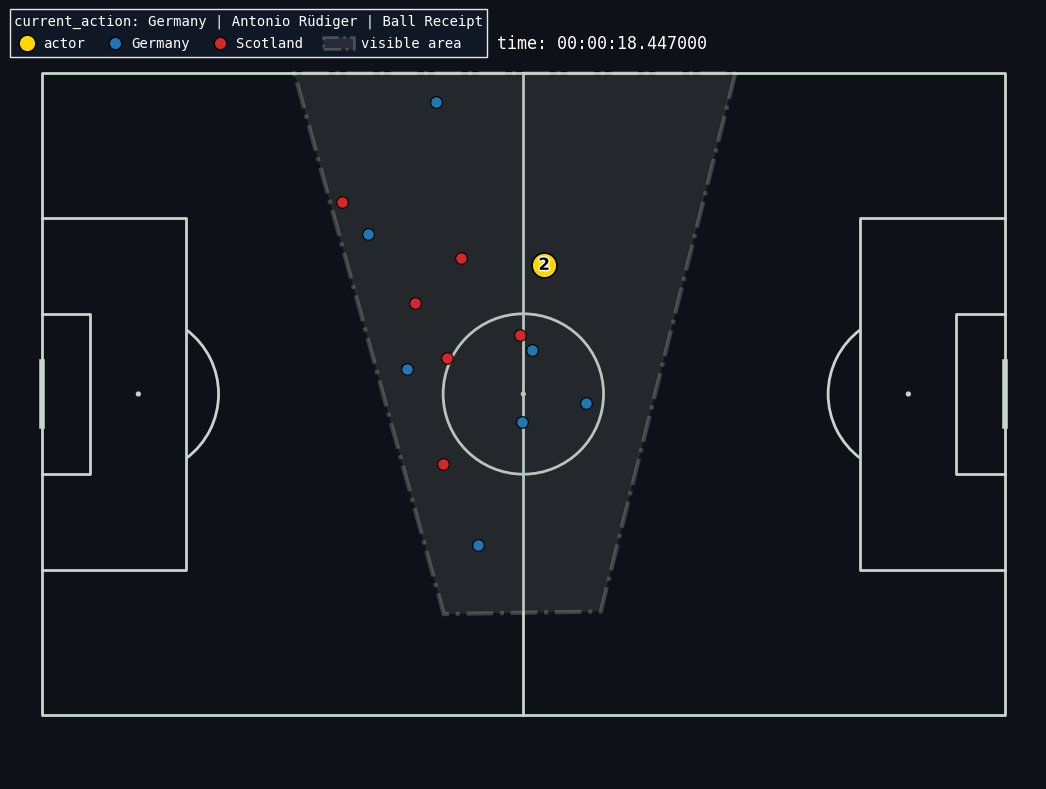

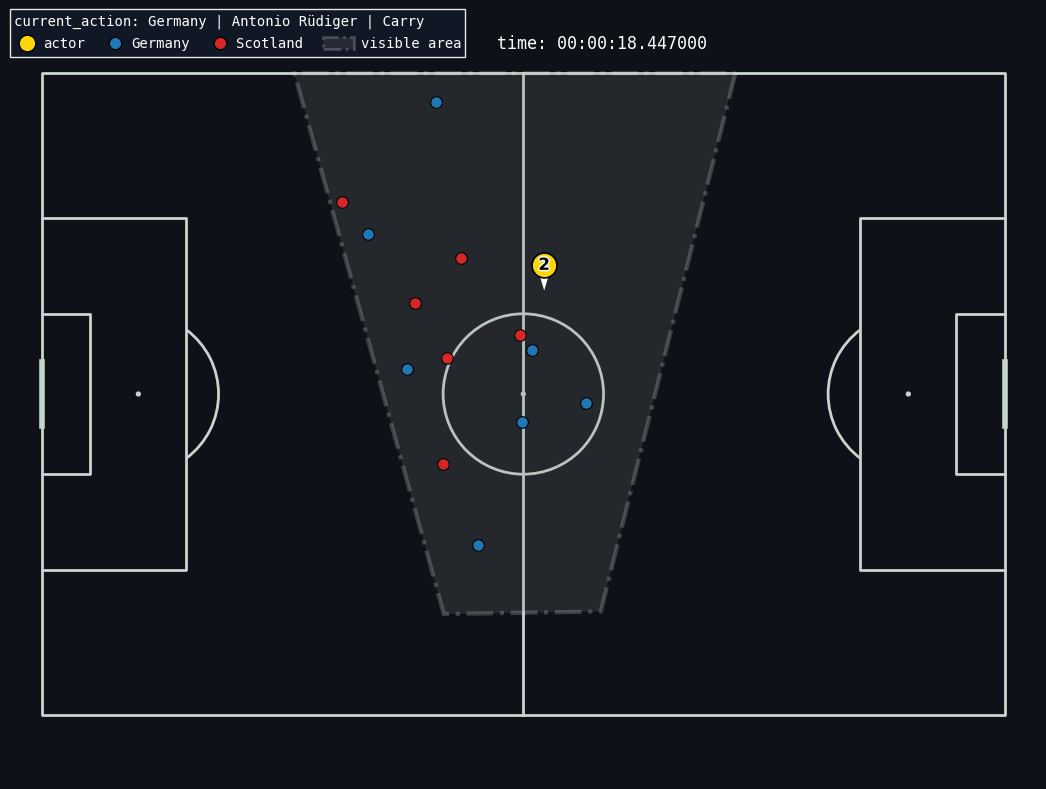

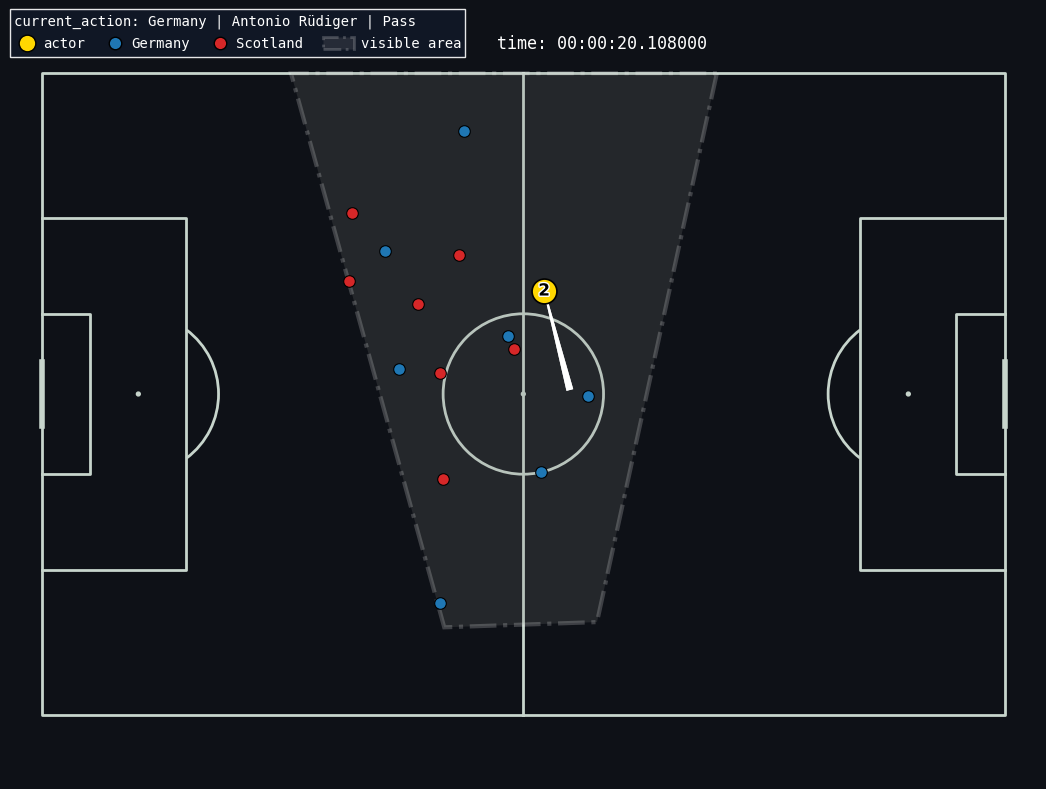

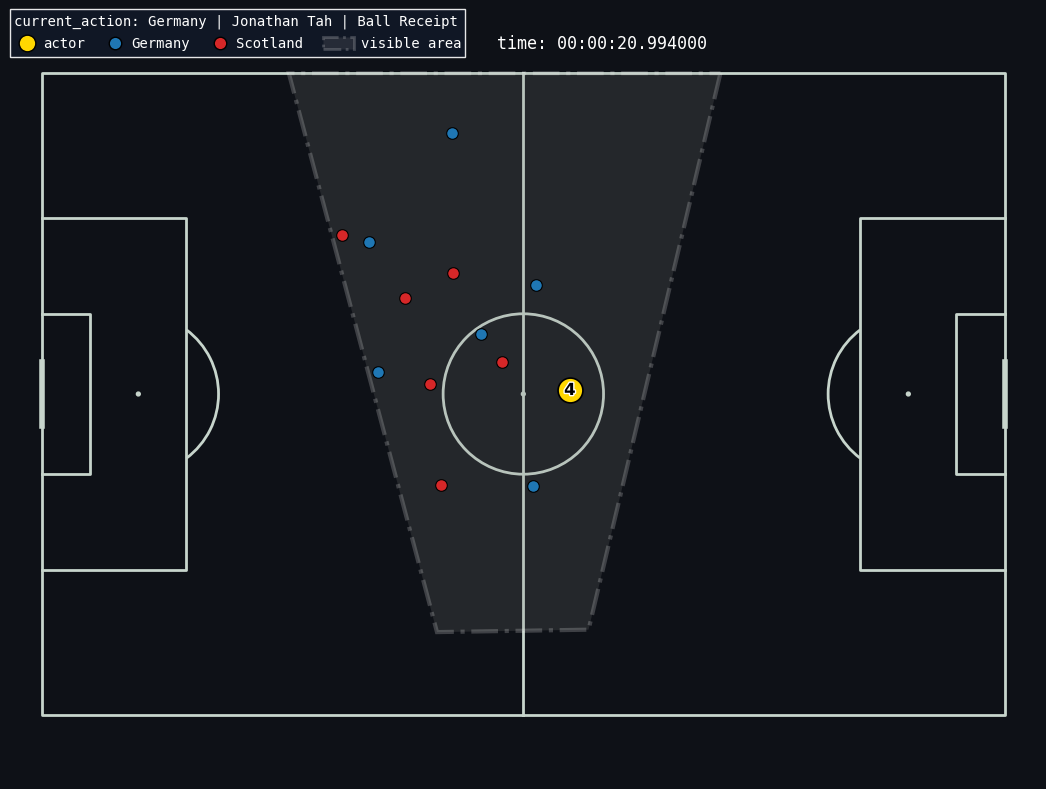

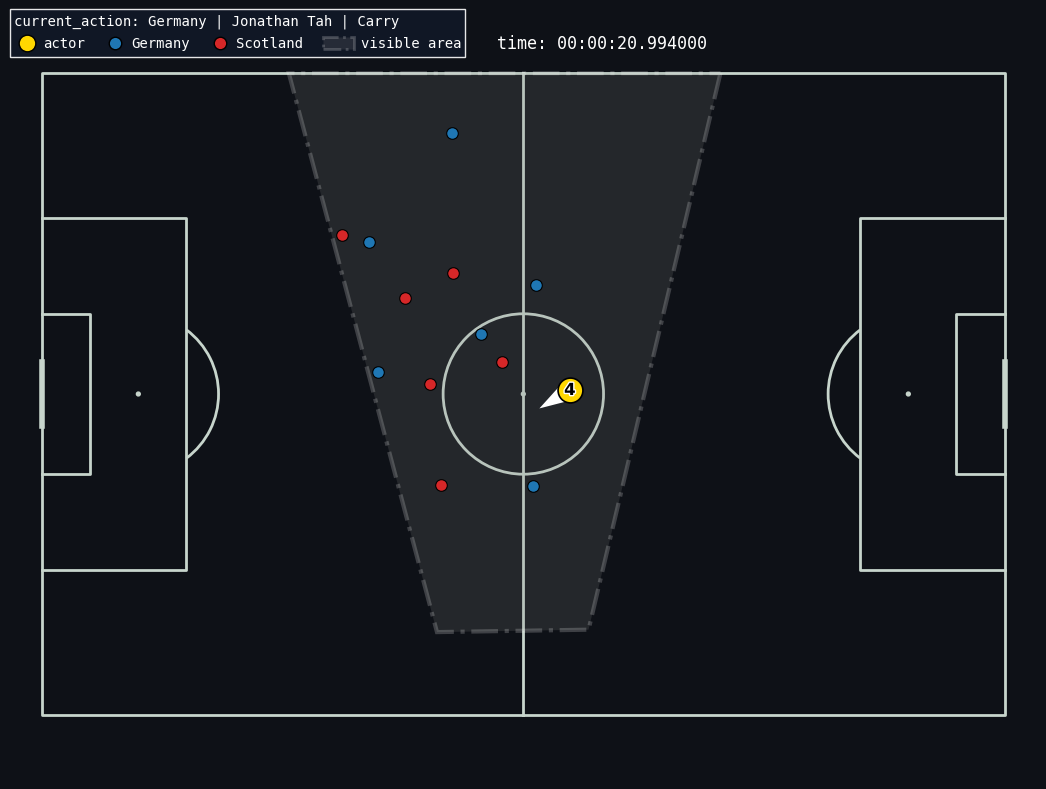

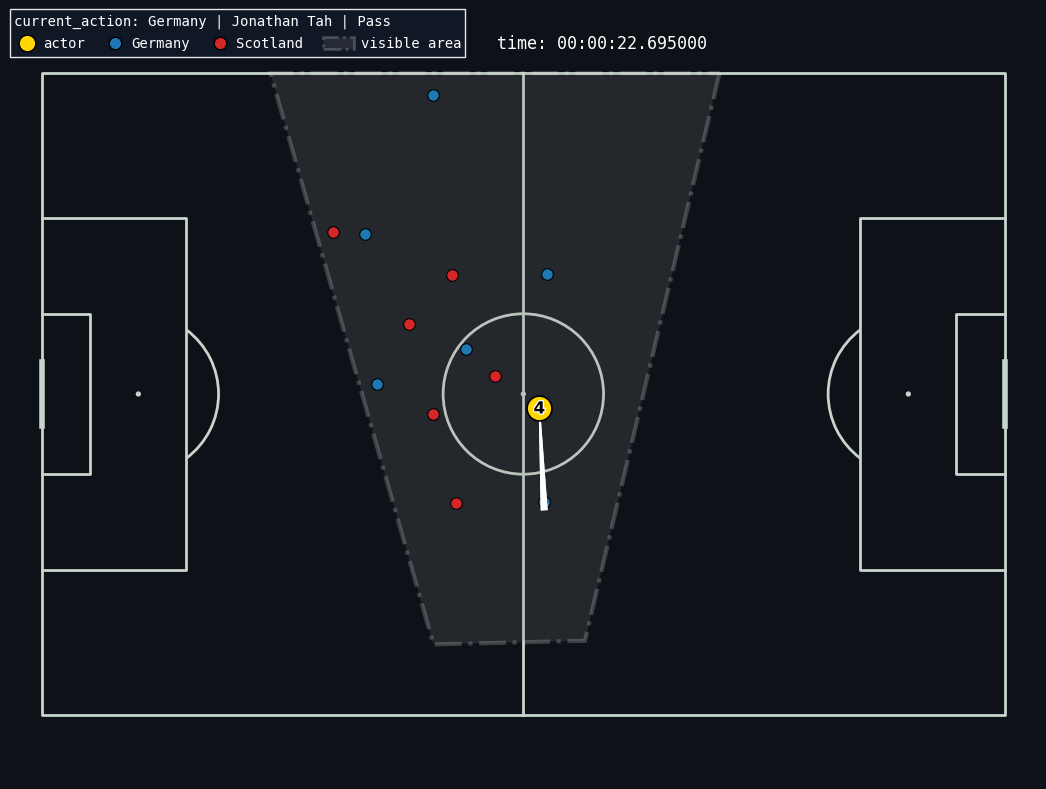

In [52]:
for _, el in slice.head(20).iterrows():
    eid = el["id"]
    fig, ax = draw_event_keep_style(df_events, eid, frames_by_id, visible_by_id)

### Только текстовая модель, без картинок

In [ ]:
for _, el in slice.head(20).iterrows():
    eid = el["id"]

    event_raw = events_by_id[eid]
    event_clean = clean_event_recursive(
        event_raw,
        keep_event_id=True,
        keep_id_paths={("player", "id")},
        drop_keys_global={"possession", "possession_team"},
        drop_paths={("pass", "angle")},
    )

    sb360_event = sb360_by_event_id.get(eid)

    result = client.generate_commentary(
        event_json=event_clean,
        sb360_json=sb360_event,
        temperature=0.03,
    )
    client.append_commentary_result_to_txt(result, "outputs/commentary_log_2.txt", event_id=eid)